In [8]:
import pandas as pd
path = "/gpfs/data/fs72297/jklotz/programming/cloned_repos/forked_repos_for_master_thesis/d3rlpy/experiments/exp01_original_dt/d3rlpy_logs/DT_hopper-medium-expert-v2_1_20250709085115/metrics.csv"
df = pd.read_csv(path)
print(df["eval_episode_mean_reward"])
print(df["eval_episode_mean_reward"][8])
print(df["eval_episode_std_reward"][8])
print(df["eval_episode_mean_reward"][4])
print(df["eval_episode_std_reward"][4])
print(df["eval_episode_mean_reward"][14])
print(df["eval_episode_std_reward"][14])

display(df)

0      421.950413
1      829.773139
2     1243.916983
3      667.227059
4     2467.208782
5     2257.912395
6     1233.311933
7     1047.180878
8     2287.853144
9     2279.714023
10    1396.704452
11    1919.226939
12    1484.310536
13    1021.993283
14    2796.691541
Name: eval_episode_mean_reward, dtype: float64
2287.8531443230395
683.8309330969912
2467.2087816082594
800.5528636934237
2796.691540945322
742.8679995366903


,epoch,step,eval_episode_count,eval_episode_max_reward,eval_episode_mean_reward,eval_episode_median_reward,eval_episode_min_reward,eval_episode_std_reward,loss,time_algorithm_update,time_sample_batch,time_step
0,1,1000,1.0,421.950413,421.950413,421.950413,421.950413,0.000000,0.716595,0.009105,0.003485,0.012667
1,2,2000,100.0,1628.606395,829.773139,726.933501,485.925413,259.540533,0.334661,0.009103,0.003456,0.012637
2,3,3000,100.0,3575.906940,1243.916983,1265.828052,490.567541,498.808414,0.289813,0.009057,0.003388,0.012523
3,4,4000,100.0,945.988717,667.227059,695.543688,468.512008,106.499498,0.267896,0.009062,0.003396,0.012536
4,5,5000,100.0,3647.667985,2467.208782,2443.180092,1087.212435,800.552864,0.254256,0.009068,0.003384,0.012530
5,6,6000,100.0,3700.055152,2257.912395,2083.771136,1032.312156,824.816319,0.244715,0.009082,0.003390,0.012549
6,7,7000,100.0,2034.669198,1233.311933,1223.592885,1048.219967,143.994964,0.238050,0.009065,0.003387,0.012529
7,8,8000,100.0,1337.715164,1047.180878,1036.057179,1011.307348,46.198258,0.232064,0.009031,0.003386,0.012494
8,9,9000,100.0,3725.094035,2287.853144,2189.854376,1057.375165,683.830933,0.227411,0.009058,0.003379,0.012514
9,10,10000,100.0,3709.270563,2279.714023,1987.820527,1045.059462,909.343898,0.223760,0.009052,0.003388,0.012517


In [7]:
# Use scipy for two-sample t-test
# If you only have summary stats, you can use the formula:

import numpy as np
from scipy import stats

mean_a = df["eval_episode_mean_reward"][4]
std_a = df["eval_episode_std_reward"][4]
n_a = 100
mean_b = df["eval_episode_mean_reward"][8]
std_b = df["eval_episode_std_reward"][8]
n_b = 100

# Pooled standard error
se = np.sqrt((std_a**2 / n_a) + (std_b**2 / n_b))
t_stat = (mean_a - mean_b) / se

# Degrees of freedom (Welch–Satterthwaite equation)
df = ( (std_a**2 / n_a) + (std_b**2 / n_b) )**2 / (
    ((std_a**2 / n_a)**2 / (n_a-1)) + ((std_b**2 / n_b)**2 / (n_b-1))
)

# One-tailed p-value for mean_a > mean_b
p_value = 1 - stats.t.cdf(t_stat, df)

alpha = 0.05

if p_value < alpha:
    print(f"Significantly better with p_value: {p_value}")
else:
    print(f"Not significantly better with p_value: {p_value}")

Significantly better with p_value: 0.045039750675604506


In [9]:
# Use scipy for two-sample t-test
# If you only have summary stats, you can use the formula:

import numpy as np
from scipy import stats

mean_a = df["eval_episode_mean_reward"][14]
std_a = df["eval_episode_std_reward"][14]
n_a = 100
mean_b = df["eval_episode_mean_reward"][4]
std_b = df["eval_episode_std_reward"][4]
n_b = 100

# Pooled standard error
se = np.sqrt((std_a**2 / n_a) + (std_b**2 / n_b))
t_stat = (mean_a - mean_b) / se

# Degrees of freedom (Welch–Satterthwaite equation)
df = ( (std_a**2 / n_a) + (std_b**2 / n_b) )**2 / (
    ((std_a**2 / n_a)**2 / (n_a-1)) + ((std_b**2 / n_b)**2 / (n_b-1))
)

# One-tailed p-value for mean_a > mean_b
p_value = 1 - stats.t.cdf(t_stat, df)

alpha = 0.05

if p_value < alpha:
    print(f"Significantly better with p_value: {p_value}")
else:
    print(f"Not significantly better with p_value: {p_value}")

Significantly better with p_value: 0.0014454447265843662


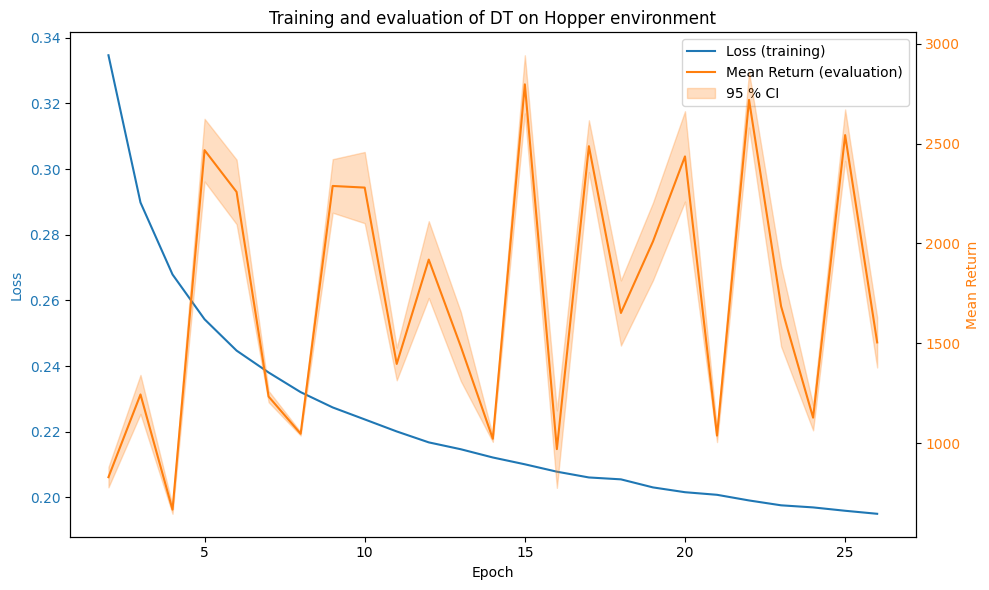

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np           # make sure this is imported

path = "/gpfs/data/fs72297/jklotz/programming/cloned_repos/forked_repos_for_master_thesis/d3rlpy/experiments/exp01_original_dt/d3rlpy_logs/DT_hopper-medium-expert-v2_1_20250709085115/metrics.csv"
df = pd.read_csv(path)
# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(10, 6))

df = df[df['epoch'] >= 2]

# Plot first file (left y-axis)
line1 = ax1.plot(df['epoch'], df['loss'], label='Loss (training)', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create second y-axis (right)
ax2 = ax1.twinx()
line2 = ax2.plot(df['epoch'], df['eval_episode_mean_reward'], label='Mean Return (evaluation)', color='tab:orange')
ax2.set_ylabel('Mean Return', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')


# --- 95 % CI for the evaluation return --------------------------
z = 1.96                      # two-tailed 95 % normal quantile
# If df['eval_episode_std_reward'] is the *standard deviation of the mean*
#   (i.e. already σ/√n), keep it as-is.
# If it is the *episode-to-episode* σ over N evaluation episodes,
#   divide by √N to get the s.e.m. before multiplying by z.
# Example if N=10 evaluation episodes each epoch:
# half_width = z * df['eval_episode_std_reward'] / np.sqrt(10)

half_width = z * df['eval_episode_std_reward'] / 10

lower = df['eval_episode_mean_reward'] - half_width
upper = df['eval_episode_mean_reward'] + half_width

# Draw the band on the same (right-hand) axis as the mean line
ci_band = ax2.fill_between(
    df['epoch'],
    lower,
    upper,
    color='tab:orange',
    alpha=0.25,
    label='95 % CI'
)

# ---------------------------------------------------------------

# Add the CI band to the combined legend
lines = line1 + line2 + [ci_band]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# # Combine legends from both axes
# lines = line1 + line2
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc='upper right')

plt.title('Training and evaluation of DT on Hopper environment')
plt.tight_layout()
plt.show()